# PCR Product Analysis by Agarose Gel Electrophoresis

**Objective:** Fit a DNA ladder standard curve and estimate PCR product
sizes from measured migration distance, confirming whether each product
matches its expected amplicon size.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("sample_data/gel_migration_data.csv")
df

,band_id,type,migration_mm,known_size_bp,expected_size_bp
0,Ladder_100,ladder,80.0,100.0,NaN
1,Ladder_200,ladder,65.0,200.0,NaN
2,Ladder_300,ladder,55.0,300.0,NaN
3,Ladder_400,ladder,48.0,400.0,NaN
4,Ladder_500,ladder,42.0,500.0,NaN
5,Ladder_600,ladder,37.0,600.0,NaN
6,Ladder_700,ladder,33.0,700.0,NaN
7,Ladder_800,ladder,29.0,800.0,NaN
8,Ladder_900,ladder,26.0,900.0,NaN
9,Ladder_1000,ladder,23.0,1000.0,NaN


## Fit the standard curve from ladder bands

In [2]:
ladder = df[df.type == "ladder"].copy()
ladder["log_size"] = np.log10(ladder.known_size_bp)

m, b = np.polyfit(ladder.migration_mm, ladder.log_size, 1)
predicted = m * ladder.migration_mm + b
ss_res = np.sum((ladder.log_size - predicted) ** 2)
ss_tot = np.sum((ladder.log_size - ladder.log_size.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot

print(f"Standard curve: log10(bp) = {m:.4f} * distance + {b:.3f}")
print(f"R-squared = {r_squared:.3f}")

Standard curve: log10(bp) = -0.0170 * distance + 3.397
R-squared = 0.998


## Estimate PCR product sizes

In [3]:
samples = df[df.type == "sample"].copy()
samples["estimated_size_bp"] = (10 ** (m * samples.migration_mm + b)).round(0)
samples["match"] = (abs(samples.estimated_size_bp - samples.expected_size_bp) / samples.expected_size_bp <= 0.15)
samples[["band_id", "migration_mm", "estimated_size_bp", "expected_size_bp", "match"]]

,band_id,migration_mm,estimated_size_bp,expected_size_bp,match
12,PCR_Product_1,58.0,258.0,230.0,True
13,PCR_Product_2,75.0,133.0,230.0,False


## Visualise the gel standard curve

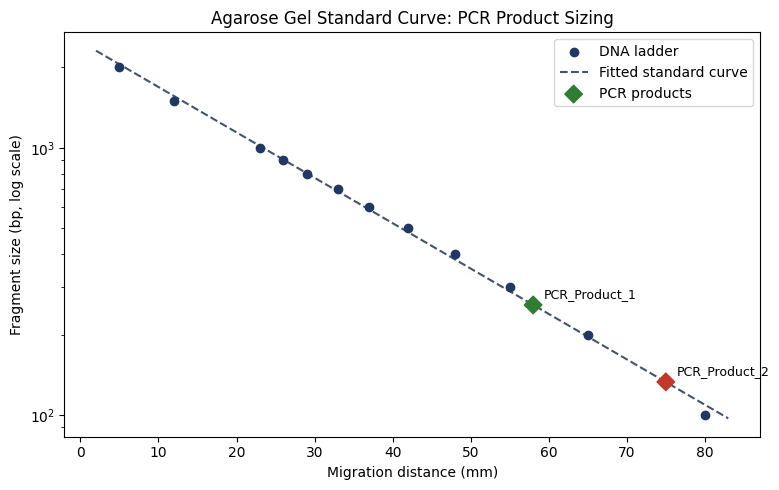

In [4]:
x_fit = np.linspace(ladder.migration_mm.min() - 3, ladder.migration_mm.max() + 3, 100)
y_fit = 10 ** (m * x_fit + b)

plt.figure(figsize=(8, 5))
plt.scatter(ladder.migration_mm, ladder.known_size_bp, color="#1F3864", label="DNA ladder", zorder=3)
plt.plot(x_fit, y_fit, color="#44546A", linestyle="--", label="Fitted standard curve", zorder=2)

match_colors = samples.match.map({True: "#2E7D32", False: "#C0392B"})
plt.scatter(samples.migration_mm, samples.estimated_size_bp, color=match_colors, marker="D", s=80, zorder=4,
            label="PCR products")

for _, row in samples.iterrows():
    plt.annotate(row.band_id, (row.migration_mm, row.estimated_size_bp),
                 textcoords="offset points", xytext=(8, 5), fontsize=9)

plt.yscale("log")
plt.xlabel("Migration distance (mm)")
plt.ylabel("Fragment size (bp, log scale)")
plt.title("Agarose Gel Standard Curve: PCR Product Sizing")
plt.legend()
plt.tight_layout()
plt.savefig("pcr_gel_standard_curve.png", dpi=150)
plt.show()

## Summary

PCR_Product_1 migrated to a size closely matching the expected 230 bp
amplicon, confirming successful, specific amplification. PCR_Product_2
migrated much further than expected, estimating to a substantially smaller
fragment size &mdash; consistent with non-specific amplification, primer
dimer formation, or primer mis-annealing, and would warrant repeating the
reaction with re-optimised primer conditions.
